# Week 4: Deep Learning in RL

## From tabular RL to deep reinforcement learning

So far, many reinforcement learning methods have been presented in a tabular form. For example, in tabular value-based learning we store one number for each state-action pair,

$$
Q(s,a),
$$

and update these values from experience. This is very useful pedagogically because every object is explicit: states, actions, rewards, returns, policies, and value functions can all be inspected directly.

However, tabular methods only work when the state and action spaces are small. In realistic problems, the state may be a high-dimensional vector, an image, a molecular configuration, a quantum state, or a robot sensor stream. In such cases, it is impossible to store a separate value for every possible state. We therefore replace tables with function approximators, often neural networks. Instead of storing $Q(s,a)$ directly, we learn a parametrized approximation

$$
Q_\theta(s,a) \approx Q(s,a),
$$

or a parametrized policy

$$
\pi_\theta(a \mid s).
$$

This is the basic step from tabular RL to deep reinforcement learning.

Once policies and values are represented by neural networks, several new algorithmic families become natural. **Policy-gradient methods** optimize the policy parameters directly to increase expected return,

$$
J(\theta) = \mathbb{E}_{\pi_\theta}[G_0].
$$

**Actor-critic methods** combine two learned objects: an actor, which represents the policy $\pi_\theta(a \mid s)$, and a critic, which estimates value, such as $V_\phi(s)$ or $Q_\phi(s,a)$. The critic helps evaluate the actor’s choices, while the actor improves the behavior.

The motivation for deep RL is therefore not to make the notation more complicated, but to make RL usable in problems where tables are impossible. Neural networks allow RL agents to generalize across similar states and learn useful behavior in large, continuous, or partially observed environments. Moreover, in complex environments, storing each possible value in a table may be infeasible, and deep RL serves as a practical circumvention.

# Neural-network update methods in reinforcement learning

In tabular reinforcement learning, we update individual entries such as

$$
V(s)
$$

or

$$
Q(s,a).
$$

With function approximation, these tables are replaced by parametrized functions, often neural networks:

$$
v_\pi(s)\approx \hat v(s;w),
$$

$$
q_\pi(s,a)\approx \hat q(s,a;w),
$$

$$
\pi(a\mid s)\approx \pi_\theta(a\mid s).
$$

The parameters $w$ or $\theta$ are then updated by gradient-based optimization. The main conceptual change is that one update may affect many states at once, because the same network parameters are shared across the state space.

In ordinary supervised learning, a network $f(x;w)$ is trained from fixed targets $y_i$. For squared-error regression,

$$
L(w)
=
\frac{1}{2}
\left[
y-f(x;w)
\right]^2.
$$

The gradient descent update is

$$
w
\leftarrow
w
-
\alpha
\nabla_w L(w),
$$

or equivalently,

$$
w
\leftarrow
w
+
\alpha
\left[
y-f(x;w)
\right]
\nabla_w f(x;w).
$$

The target $y$ is fixed. This is not generally true in reinforcement learning.

For Monte Carlo value approximation, the target is a sampled return $G_t$. The value network is trained using

$$
L_t(w)
=
\frac{1}{2}
\left[
G_t-\hat v(S_t;w)
\right]^2,
$$

which gives the update

$$
w
\leftarrow
w
+
\alpha
\left[
G_t-\hat v(S_t;w)
\right]
\nabla_w \hat v(S_t;w).
$$

This is the function-approximation version of

$$
V(S_t)
\leftarrow
V(S_t)
+
\alpha
\left[
G_t-V(S_t)
\right].
$$

The update is based on a complete return, so it is unbiased as a sample of the return but can have high variance.

Temporal-difference learning replaces the complete return by a bootstrapped target:

$$
Y_t
=
R_{t+1}
+
\gamma
\hat v(S_{t+1};w).
$$

The TD error is

$$
\delta_t
=
R_{t+1}
+
\gamma
\hat v(S_{t+1};w)
-
\hat v(S_t;w).
$$

A standard TD update with function approximation is

$$
w
\leftarrow
w
+
\alpha
\delta_t
\nabla_w\hat v(S_t;w).
$$

This is called a semi-gradient update because the target is treated as fixed during the gradient step. The gradient is taken only through the current prediction $\hat v(S_t;w)$, not through the next-state value inside the target.

For Q-learning with a neural network, we approximate

$$
q_*(s,a)\approx \hat q(s,a;w).
$$

The target is

$$
Y_t
=
R_{t+1}
+
\gamma
\max_{a'}
\hat q(S_{t+1},a';w),
$$

and the semi-gradient update is

$$
w
\leftarrow
w
+
\alpha
\left[
Y_t-\hat q(S_t,A_t;w)
\right]
\nabla_w\hat q(S_t,A_t;w).
$$

In deep Q-learning, the target is often computed using a separate target network with parameters $w^-$:

$$
Y_t
=
R_{t+1}
+
\gamma
\max_{a'}
\hat q(S_{t+1},a';w^-).
$$

The target network changes more slowly than the online network and helps reduce instability.

Policy-gradient methods update the policy directly. A stochastic policy is written as

$$
\pi_\theta(a\mid s).
$$

The objective is

$$
J(\theta)
=
E_{\pi_\theta}[G_0].
$$

The REINFORCE update is

$$
\theta
\leftarrow
\theta
+
\alpha
\sum_{t=0}^{T-1}
\nabla_\theta
\log \pi_\theta(A_t\mid S_t)
G_t.
$$

This increases the probability of actions followed by high return and decreases the probability of actions followed by low return.

Actor--critic methods combine a policy network and a value network. The actor is

$$
\pi_\theta(a\mid s),
$$

and the critic is

$$
\hat v(s;w).
$$

The critic computes the TD error

$$
\delta_t
=
R_{t+1}
+
\gamma
\hat v(S_{t+1};w)
-
\hat v(S_t;w).
$$

The critic is updated by semi-gradient TD:

$$
w
\leftarrow
w
+
\alpha_w
\delta_t
\nabla_w\hat v(S_t;w).
$$

The actor is updated using the TD error as an advantage estimate:

$$
\theta
\leftarrow
\theta
+
\alpha_\theta
\delta_t
\nabla_\theta
\log\pi_\theta(A_t\mid S_t).
$$

Thus, value-based methods train networks to match targets, while policy-gradient methods change action probabilities. Actor--critic methods do both: the critic learns a value function, and the actor uses the critic's feedback to improve the policy.

| Method | Network output | Learning signal | Update idea |
|---|---|---|---|
| Supervised SGD | $f(x;w)$ | fixed target $y$ | fit prediction to label |
| Monte Carlo value learning | $\hat v(s;w)$ | return $G_t$ | fit value to complete return |
| TD value learning | $\hat v(s;w)$ | TD target $R+\gamma\hat v(s';w)$ | semi-gradient bootstrapping |
| Deep Q-learning | $\hat q(s,a;w)$ | max-Q target | semi-gradient control |
| REINFORCE | $\pi_\theta(a\mid s)$ | return $G_t$ | increase probability of good actions |
| Actor--critic | $\pi_\theta$, $\hat v$ | TD error $\delta_t$ | policy update plus critic update |
```


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


torch.manual_seed(1)
np.random.seed(1)


class LineWorld:
    """
    Random-walk control/evaluation toy problem.

    States: 0, 1, 2, 3, 4
    Start: 2
    Terminal states: 0 and 4
    Reward: +1 at state 4, 0 otherwise
    Actions: 0 = left, 1 = right

    Under the random policy, the exact value is

        v(s) = s / 4.

    This makes the plots interpretable.
    """

    def __init__(self):
        self.n_states = 5
        self.n_actions = 2
        self.start_state = 2

    def reset(self):
        self.state = self.start_state
        return self.state

    def state_tensor(self, state):
        x = state / (self.n_states - 1)
        return torch.tensor([[x]], dtype=torch.float32)

    def step(self, action):
        self.state += 1 if action == 1 else -1

        done = self.state in [0, self.n_states - 1]
        reward = 1.0 if self.state == self.n_states - 1 else 0.0

        return self.state, reward, done


class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, s):
        return self.net(s)


class PolicyNet(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, n_actions),
        )

    def forward(self, s):
        logits = self.net(s)
        return torch.distributions.Categorical(logits=logits)


def exact_value(state):
    return state / 4.0


def random_action():
    return np.random.choice([0, 1])


def returns_from_rewards(rewards, gamma=1.0):
    G = 0.0
    returns = []

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.append(G)

    return list(reversed(returns))

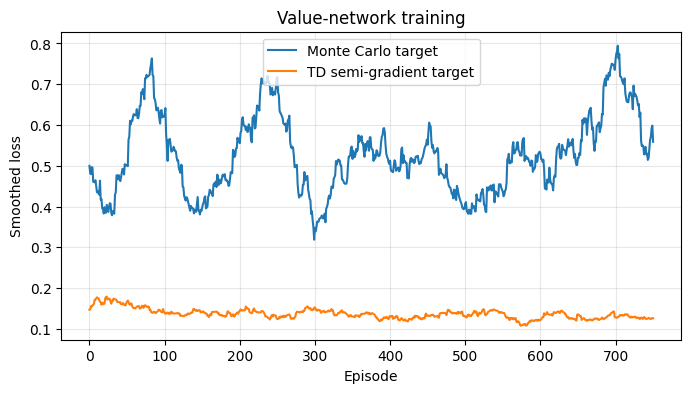

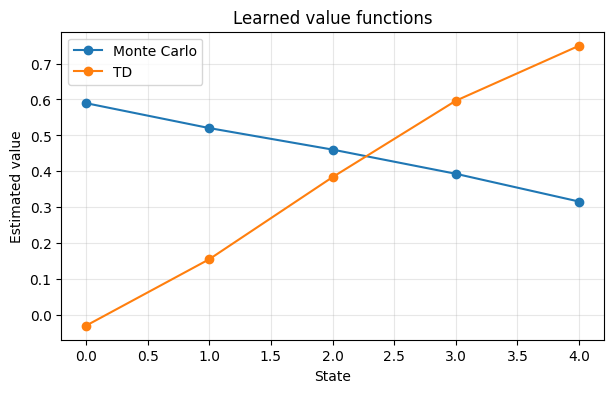

In [6]:
def train_mc_value(episodes=800, gamma=1.0):
    env = LineWorld()
    net = ValueNet()
    optimizer = optim.Adam(net.parameters(), lr=0.02)

    losses = []

    for _ in range(episodes):
        states = []
        rewards = []

        state = env.reset()
        done = False

        while not done:
            action = np.random.choice([0, 1])
            states.append(state)

            state, reward, done = env.step(action)
            rewards.append(reward)

        returns = returns_from_rewards(rewards, gamma)

        episode_loss = 0.0

        for state, G in zip(states, returns):
            s = env.state_tensor(state)
            target = torch.tensor([[G]], dtype=torch.float32)

            prediction = net(s)
            loss = 0.5 * (target - prediction) ** 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            episode_loss += loss.item()

        losses.append(episode_loss)

    return net, losses


def train_td_value(episodes=800, gamma=1.0):
    env = LineWorld()
    net = ValueNet()
    optimizer = optim.Adam(net.parameters(), lr=0.02)

    losses = []

    for _ in range(episodes):
        state = env.reset()
        done = False
        episode_loss = 0.0

        while not done:
            action = np.random.choice([0, 1])
            next_state, reward, done = env.step(action)

            s = env.state_tensor(state)
            sp = env.state_tensor(next_state)

            prediction = net(s)

            with torch.no_grad():
                if done:
                    target = torch.tensor([[reward]], dtype=torch.float32)
                else:
                    target = torch.tensor([[reward]], dtype=torch.float32) + gamma * net(sp)

            loss = 0.5 * (target - prediction) ** 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            episode_loss += loss.item()
            state = next_state

        losses.append(episode_loss)

    return net, losses


mc_net, mc_losses = train_mc_value()
td_net, td_losses = train_td_value()

plt.figure(figsize=(8, 4))
plt.plot(moving_average(mc_losses), label="Monte Carlo target")
plt.plot(moving_average(td_losses), label="TD semi-gradient target")
plt.xlabel("Episode")
plt.ylabel("Smoothed loss")
plt.title("Value-network training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


env = LineWorld()
states = range(env.n_states)

with torch.no_grad():
    mc_values = [
        mc_net(env.state_tensor(s)).item()
        for s in states
    ]

    td_values = [
        td_net(env.state_tensor(s)).item()
        for s in states
    ]

plt.figure(figsize=(7, 4))
plt.plot(states, mc_values, marker="o", label="Monte Carlo")
plt.plot(states, td_values, marker="o", label="TD")
plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Learned value functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

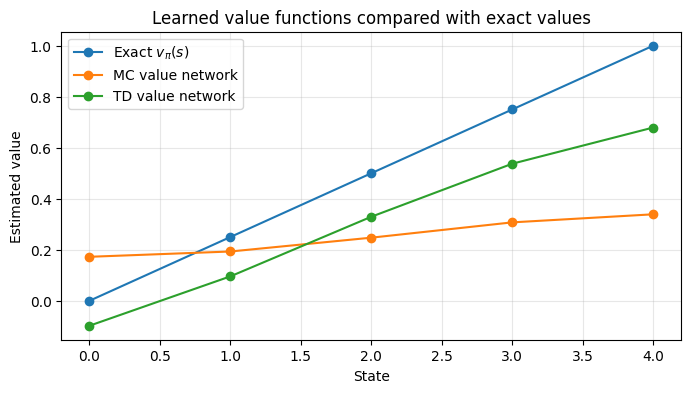

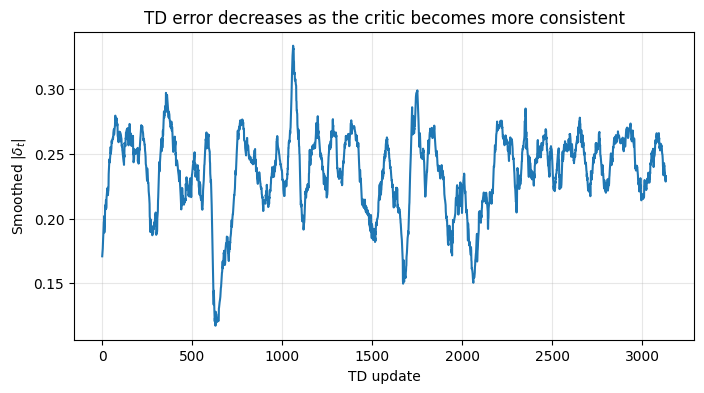

In [7]:
def train_mc_value(episodes=800, gamma=1.0):
    env = LineWorld()
    net = ValueNet()
    optimizer = optim.Adam(net.parameters(), lr=0.02)

    value_history = []

    for episode in range(episodes):
        states = []
        rewards = []

        state = env.reset()
        done = False

        while not done:
            states.append(state)

            action = random_action()
            state, reward, done = env.step(action)

            rewards.append(reward)

        returns = returns_from_rewards(rewards, gamma)

        for state, G in zip(states, returns):
            s = env.state_tensor(state)
            target = torch.tensor([[G]], dtype=torch.float32)

            prediction = net(s)
            loss = 0.5 * (target - prediction) ** 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if episode % 20 == 0:
            with torch.no_grad():
                value_history.append([
                    net(env.state_tensor(s)).item()
                    for s in range(env.n_states)
                ])

    return net, np.asarray(value_history)


def train_td_value(episodes=800, gamma=1.0):
    env = LineWorld()
    net = ValueNet()
    optimizer = optim.Adam(net.parameters(), lr=0.02)

    value_history = []
    td_errors = []

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = random_action()
            next_state, reward, done = env.step(action)

            s = env.state_tensor(state)
            sp = env.state_tensor(next_state)

            prediction = net(s)

            with torch.no_grad():
                if done:
                    target = torch.tensor([[reward]], dtype=torch.float32)
                else:
                    target = (
                        torch.tensor([[reward]], dtype=torch.float32)
                        + gamma * net(sp)
                    )

                delta = target - prediction

            loss = 0.5 * (target - prediction) ** 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            td_errors.append(delta.item())
            state = next_state

        if episode % 20 == 0:
            with torch.no_grad():
                value_history.append([
                    net(env.state_tensor(s)).item()
                    for s in range(env.n_states)
                ])

    return net, np.asarray(value_history), np.asarray(td_errors)


mc_net, mc_value_history = train_mc_value()
td_net, td_value_history, td_errors = train_td_value()

states = np.arange(5)
exact = np.array([exact_value(s) for s in states])

with torch.no_grad():
    mc_final = np.array([
        mc_net(LineWorld().state_tensor(s)).item()
        for s in states
    ])

    td_final = np.array([
        td_net(LineWorld().state_tensor(s)).item()
        for s in states
    ])

plt.figure(figsize=(8, 4))

plt.plot(states, exact, marker="o", label="Exact $v_\\pi(s)$")
plt.plot(states, mc_final, marker="o", label="MC value network")
plt.plot(states, td_final, marker="o", label="TD value network")

plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Learned value functions compared with exact values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 4))

plt.plot(
    np.convolve(
        np.abs(td_errors),
        np.ones(50) / 50,
        mode="valid",
    )
)

plt.xlabel("TD update")
plt.ylabel("Smoothed $|\\delta_t|$")
plt.title("TD error decreases as the critic becomes more consistent")
plt.grid(alpha=0.3)
plt.show()

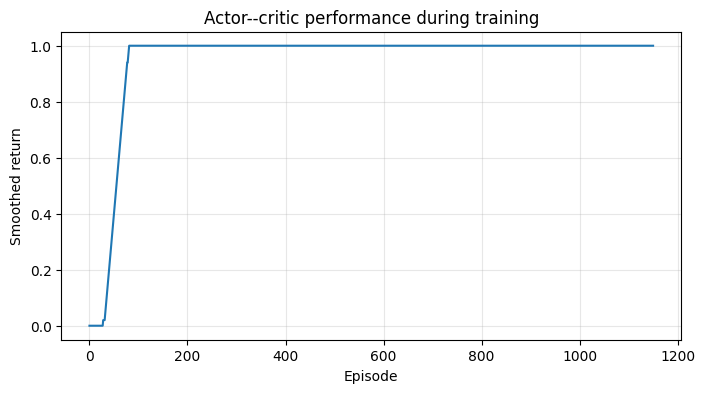

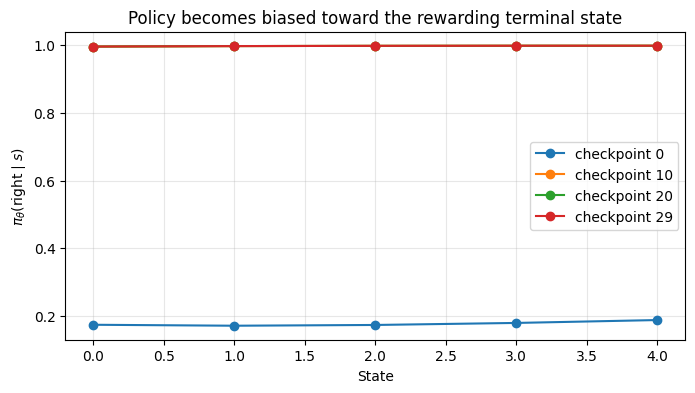

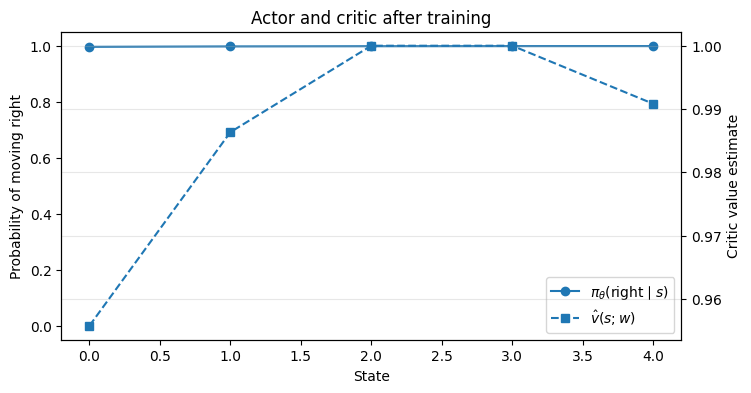

In [8]:
def train_actor_critic(episodes=1200, gamma=1.0):
    env = LineWorld()

    actor = PolicyNet(env.n_actions)
    critic = ValueNet()

    actor_optimizer = optim.Adam(actor.parameters(), lr=0.01)
    critic_optimizer = optim.Adam(critic.parameters(), lr=0.02)

    returns = []
    policy_history = []
    critic_history = []

    for episode in range(episodes):
        state = env.reset()
        done = False

        total_return = 0.0
        discount = 1.0

        while not done:
            s = env.state_tensor(state)
            distribution = actor(s)

            action_tensor = distribution.sample()
            action = int(action_tensor.item())
            log_prob = distribution.log_prob(action_tensor)

            next_state, reward, done = env.step(action)
            sp = env.state_tensor(next_state)

            value = critic(s)

            with torch.no_grad():
                if done:
                    target = torch.tensor([[reward]], dtype=torch.float32)
                else:
                    target = (
                        torch.tensor([[reward]], dtype=torch.float32)
                        + gamma * critic(sp)
                    )

                delta = target - value

            critic_loss = 0.5 * (target - value) ** 2

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            actor_loss = -log_prob * delta.item()

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            total_return += discount * reward
            discount *= gamma
            state = next_state

        returns.append(total_return)

        if episode % 40 == 0:
            with torch.no_grad():
                policy_history.append([
                    actor(env.state_tensor(s)).probs[0, 1].item()
                    for s in range(env.n_states)
                ])

                critic_history.append([
                    critic(env.state_tensor(s)).item()
                    for s in range(env.n_states)
                ])

    return actor, critic, np.asarray(returns), np.asarray(policy_history), np.asarray(critic_history)


actor, critic, returns, policy_history, critic_history = train_actor_critic()

plt.figure(figsize=(8, 4))

plt.plot(
    np.convolve(
        returns,
        np.ones(50) / 50,
        mode="valid",
    )
)

plt.xlabel("Episode")
plt.ylabel("Smoothed return")
plt.title("Actor--critic performance during training")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 4))

for idx in [0, len(policy_history)//3, 2*len(policy_history)//3, -1]:
    plt.plot(
        states,
        policy_history[idx],
        marker="o",
        label=f"checkpoint {idx if idx >= 0 else len(policy_history)-1}",
    )

plt.xlabel("State")
plt.ylabel("$\\pi_\\theta(\\mathrm{right}\\mid s)$")
plt.title("Policy becomes biased toward the rewarding terminal state")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


with torch.no_grad():
    final_policy = np.array([
        actor(LineWorld().state_tensor(s)).probs[0, 1].item()
        for s in states
    ])

    final_critic = np.array([
        critic(LineWorld().state_tensor(s)).item()
        for s in states
    ])

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(
    states,
    final_policy,
    marker="o",
    label="$\\pi_\\theta(\\mathrm{right}\\mid s)$",
)

ax1.set_xlabel("State")
ax1.set_ylabel("Probability of moving right")
ax1.set_ylim(-0.05, 1.05)

ax2 = ax1.twinx()

ax2.plot(
    states,
    final_critic,
    marker="s",
    linestyle="--",
    label="$\\hat v(s;w)$",
)

ax2.set_ylabel("Critic value estimate")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="lower right",
)

plt.title("Actor and critic after training")
plt.grid(alpha=0.3)
plt.show()

## Interpreting the plots

The target-comparison plot shows the difference between Monte Carlo and temporal-difference learning at the level of the target itself. The Monte Carlo target is the complete return

$$
G_t,
$$

while the TD target is

$$
R_{t+1}+\gamma\hat v(S_{t+1};w).
$$

Both are trying to estimate the same value function under the random policy, but they do so differently. The Monte Carlo target waits until the end of the episode. The TD target uses the next reward and the current value estimate of the next state. The error bars show that Monte Carlo targets can vary substantially from episode to episode, while TD targets are shaped by the current critic.

The value-function plot compares the learned value networks with the exact value function for this small environment. Since the right terminal state gives reward $1$ and the left terminal gives reward $0$, the exact value increases from left to right. This plot is useful because it gives a real reference curve, not just a training loss. A successful method should recover the monotone structure of the value function.

The TD-error plot shows the magnitude of

$$
\delta_t
=
R_{t+1}
+
\gamma\hat v(S_{t+1};w)
-
\hat v(S_t;w).
$$

As learning progresses, the critic becomes more self-consistent with the Bellman relation. The smoothed absolute TD error should therefore decrease. This plot directly visualizes what TD learning is trying to reduce.

The actor--critic return plot shows whether the policy is actually improving. Early in training, the actor may frequently move left and terminate with reward $0$. As the actor learns, it should more often reach the right terminal state and obtain return $1$.

The policy-checkpoint plot shows how the actor changes over training. The plotted quantity is

$$
\pi_\theta(\mathrm{right}\mid s).
$$

A successful policy assigns high probability to moving right from the nonterminal states. This is more informative than only plotting return because it shows what behavior the policy has learned.

The final actor--critic plot overlays the learned policy and the learned critic. The actor gives the probability of moving right, while the critic estimates

$$
\hat v(s;w).
$$

The two should tell a consistent story: states closer to the rewarding terminal should have higher critic values, and the actor should choose actions that move toward those higher-value states.